In [18]:
library(data.table)
library(ggplot2)
setwd('/well/lindgren/UKBIOBANK/flassen/projects/KO/wes_ko_ukbb')

In [24]:
files = list.files('data/saige/output/combined/binary/step2/', full.names = TRUE)
x <- fread('data/saige/output/combined/binary/step2//ukb_wes_200k_af50_ptv_coronary_artery_disease_chr1')
y <- fread('data/saige/output/combined/binary/step2//ukb_wes_200k_af50_ptv_damaging_missense_coronary_artery_disease_chr1')
print(head(x$p.value)); print(head(y$p.value))



[1] 0.49797640 0.87075199 0.04974809 0.19841967 0.31910624 0.80677891
[1] 0.4103006 0.6128654 0.5316541 0.4979764 0.3199111 0.3313961


In [29]:
build_dt_by_keyword <- function(files, phenotype = 'Crohns'){
    categories <- c('ptv','ptv_damaging_missense','synonymous')
    csq_list <- lapply(categories, function(category){
        regex <- paste0(category,'_',phenotype) 
        csqs_files <- files[grepl(regex, files)]
        mat <- do.call(rbind, lapply(csqs_files, function(f){
            return(fread(f))
        }))
        n <- nrow(mat)
        mat$csqs <- category
        mat$FDR <- stats::p.adjust(mat$p.value, method = 'fdr')
        mat <- mat[order(mat$p.value),]
        mat$p.value.observed <- mat$p.value
        mat$p.value.expected <- seq(1, n)/(n + 1)
        return(mat)
    })
    names(csq_list) <- categories
    return(csq_list)
}

In [37]:
lst <- build_dt_by_keyword(files, 'coronary_artery_disease')
mat <- do.call(rbind, lst)

In [39]:
head(lst[[1]])
head(lst[[2]])

CHR,POS,SNPID,Allele1,Allele2,AC_Allele2,AF_Allele2,imputationInfo,N,BETA,⋯,N.Cases,N.Controls,homN_Allele2_cases,hetN_Allele2_cases,homN_Allele2_ctrls,hetN_Allele2_ctrls,csqs,FDR,p.value.observed,p.value.expected
<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<dbl>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>
chr7,1,ENSG00000136297,X,Y,4,1.640339e-05,1,121926,2.2827084,⋯,17065,104861,2,0,0,0,ptv,0.1016623,0.0003479952,0.002262443
chr10,1,ENSG00000188611,X,Y,26,1.066221e-04,1,121926,1.8585878,⋯,17065,104861,6,0,7,0,ptv,0.1016623,0.0004610537,0.004524887
chr11,1,ENSG00000167359,X,Y,122,5.003035e-04,1,121926,0.5578242,⋯,17065,104861,17,0,44,0,ptv,0.4610911,0.0031366744,0.006787330
chr6,1,ENSG00000124749,X,Y,4,1.640339e-05,1,121926,2.2153755,⋯,17065,104861,2,0,0,0,ptv,0.8726670,0.0122051599,0.009049774
chr10,1,ENSG00000099290,X,Y,12,4.921018e-05,1,121926,1.5543086,⋯,17065,104861,3,0,3,0,ptv,0.8726670,0.0140563713,0.011312217
chr9,1,ENSG00000187796,X,Y,6,2.460509e-05,1,121926,2.2204429,⋯,17065,104861,2,0,1,0,ptv,0.8726670,0.0180174253,0.013574661


CHR,POS,SNPID,Allele1,Allele2,AC_Allele2,AF_Allele2,imputationInfo,N,BETA,⋯,N.Cases,N.Controls,homN_Allele2_cases,hetN_Allele2_cases,homN_Allele2_ctrls,hetN_Allele2_ctrls,csqs,FDR,p.value.observed,p.value.expected
<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<dbl>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>
chr12,1,ENSG00000129317,X,Y,4,1.640339e-05,1,121926,3.14959627,⋯,17065,104861,2,0,0,0,ptv_damaging_missense,0.00000000,0.000000e+00,0.0008278146
chr19,1,ENSG00000130876,X,Y,3,1.230254e-05,1,121926,2.49921551,⋯,17065,104861,1,1,0,0,ptv_damaging_missense,0.03198388,6.994775e-05,0.0016556291
chr3,1,ENSG00000225697,X,Y,4,1.640339e-05,1,121926,2.62614114,⋯,17065,104861,2,0,0,0,ptv_damaging_missense,0.03198388,7.949596e-05,0.0024834437
chr7,1,ENSG00000136297,X,Y,4,1.640339e-05,1,121926,2.28270838,⋯,17065,104861,2,0,0,0,ptv_damaging_missense,0.10500756,3.479952e-04,0.0033112583
chr10,1,ENSG00000188611,X,Y,26,1.066221e-04,1,121926,1.85858778,⋯,17065,104861,6,0,7,0,ptv_damaging_missense,0.11129836,4.610537e-04,0.0041390728
chr20,1,ENSG00000100994,X,Y,8810,3.612847e-02,1,121926,0.07851017,⋯,17065,104861,697,6,3697,16,ptv_damaging_missense,0.11988832,5.959651e-04,0.0049668874


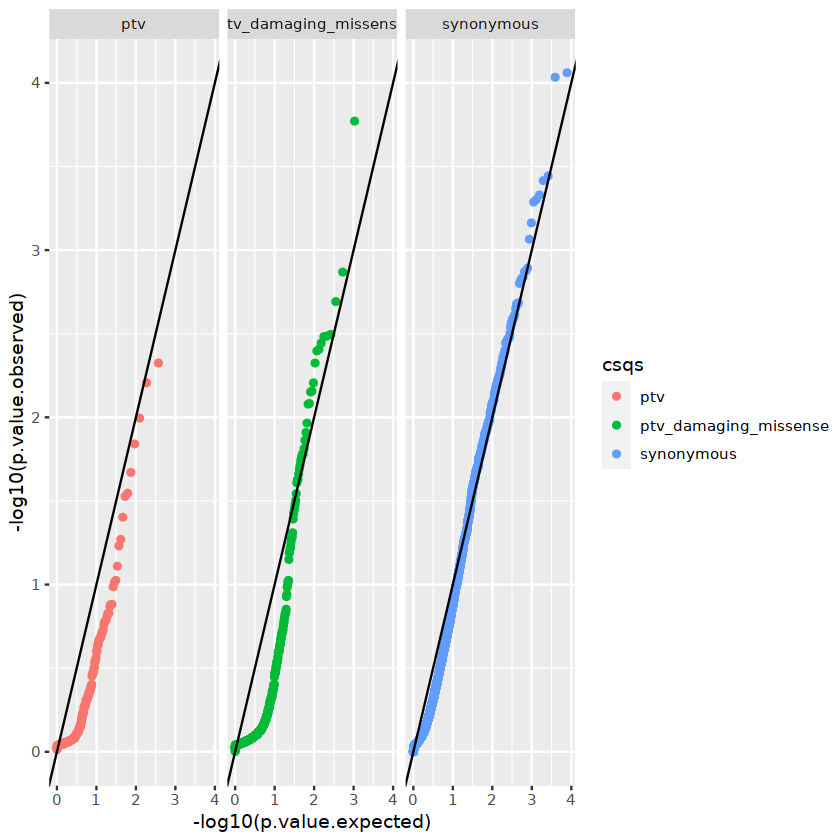

In [36]:
ggplot(mat, aes(x=-log10(p.value.expected), y=-log10(p.value.observed), color = csqs)) + 
    geom_point() + 
    geom_abline() +
    facet_wrap(~csqs)

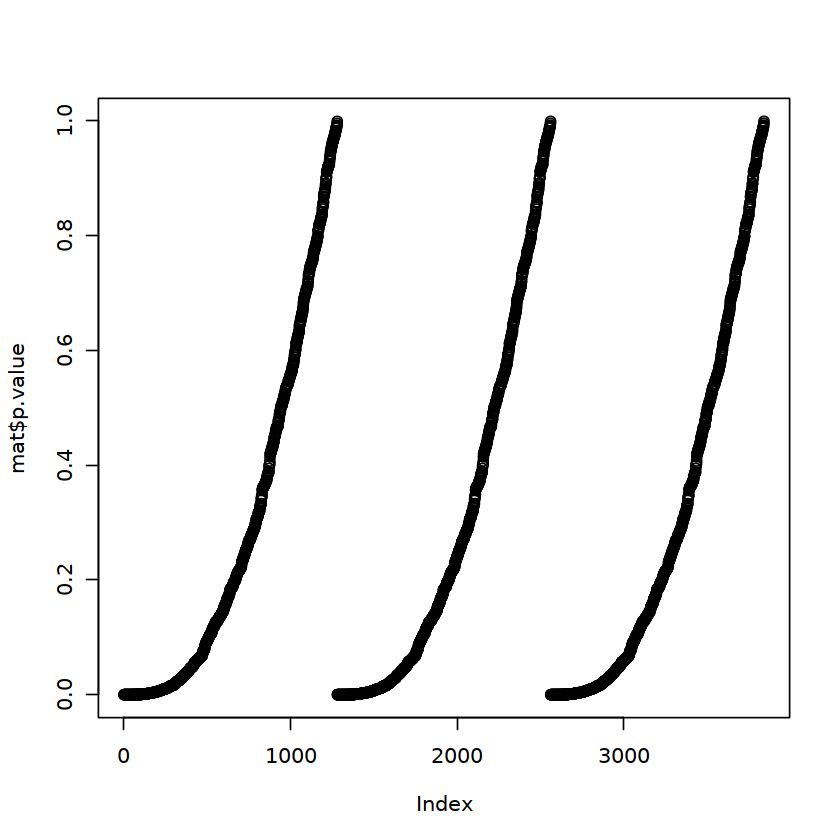

In [161]:
plot(mat$p.value)